In [5]:
!pip install -q --upgrade pillow==10.4.0 facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.6 MB/s eta 0:00:00


In [1]:
!pip install -q timm facenet-pytorch kaggle
from google.colab import files
print("Upload kaggle.json now:")
files.upload()   # click Choose Files → select kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.

Saving kaggle.json to kaggle.json


In [1]:
!pip install -q timm facenet-pytorch
# kaggle.json already in place, dataset already downloaded
!ls /content/celebdf

Celeb-real  Celeb-synthesis  List_of_testing_videos.txt  YouTube-real


In [2]:
!kaggle datasets download -d reubensuju/celeb-df-v2
!unzip -q celeb-df-v2.zip -d /content/celebdf
!ls /content/celebdf

Dataset URL: https://www.kaggle.com/datasets/reubensuju/celeb-df-v2
License(s): unknown
celeb-df-v2.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/celebdf/Celeb-real/id0_0000.mp4? [y]es, [n]o, [A]ll, [N]one, [r]ename: Celeb-real  Celeb-synthesis  List_of_testing_videos.txt  YouTube-real


In [7]:
import os, random
random.seed(42)

BASE = '/content/celebdf'
real_dir = f'{BASE}/Celeb-real'
fake_dir = f'{BASE}/Celeb-synthesis'

real_all = [f'{real_dir}/{v}' for v in os.listdir(real_dir) if v.endswith('.mp4')]
fake_all = [f'{fake_dir}/{v}' for v in os.listdir(fake_dir) if v.endswith('.mp4')]
print(f"Available: {len(real_all)} real, {len(fake_all)} fake")

# ↓ CHANGED: 50 → 100
real_sel = random.sample(real_all, 100)
fake_sel = random.sample(fake_all, 100)

# ↓ CHANGED: 40/10 split → 80/20 split (per class)
train_vids = [(v, 0) for v in real_sel[:80]] + [(v, 1) for v in fake_sel[:80]]
test_vids  = [(v, 0) for v in real_sel[80:]] + [(v, 1) for v in fake_sel[80:]]
random.shuffle(train_vids)
print(f"Train: {len(train_vids)} videos | Test: {len(test_vids)} videos")

Available: 590 real, 5639 fake
Train: 160 videos | Test: 40 videos


In [8]:
import cv2, torch, numpy as np
from facenet_pytorch import MTCNN
from PIL import Image

device = 'cuda'
mtcnn = MTCNN(image_size=224, margin=20, post_process=False, device=device)

def extract_faces(video_path, n_frames=10):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release(); return []
    idxs = np.linspace(0, total - 1, n_frames).astype(int)
    faces = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret: continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face = mtcnn(Image.fromarray(frame))
        if face is not None:
            faces.append(face)
    cap.release()
    return faces

def build_dataset(video_list, name):
    X, y, vid_ids = [], [], []
    for i, (vpath, label) in enumerate(video_list):
        faces = extract_faces(vpath)
        for f in faces:
            X.append(f); y.append(label); vid_ids.append(i)
        if i % 10 == 0: print(f"{name}: {i}/{len(video_list)}")
    return torch.stack(X), torch.tensor(y), torch.tensor(vid_ids)

print("Extracting training faces...")
X_train, y_train, _ = build_dataset(train_vids, "train")
print("Extracting test faces...")
X_test, y_test, vid_test = build_dataset(test_vids, "test")
print(f"\nDone. Shapes: X_train={X_train.shape}, X_test={X_test.shape}")

Extracting training faces...
train: 0/160
train: 10/160
train: 20/160
train: 30/160
train: 40/160
train: 50/160
train: 60/160
train: 70/160
train: 80/160
train: 90/160
train: 100/160
train: 110/160
train: 120/160
train: 130/160
train: 140/160
train: 150/160
Extracting test faces...
test: 0/40
test: 10/40
test: 20/40
test: 30/40

Done. Shapes: X_train=torch.Size([1600, 3, 224, 224]), X_test=torch.Size([399, 3, 224, 224])


In [9]:
import timm
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Normalize (MTCNN outputs [0,255] float tensors)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1) * 255
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) * 255
X_train_n = (X_train - mean) / std
X_test_n  = (X_test  - mean) / std

train_loader = DataLoader(TensorDataset(X_train_n, y_train), batch_size=32, shuffle=True)

model = timm.create_model('tf_efficientnet_b0', pretrained=True, num_classes=2).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
crit  = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    correct, total, running = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        running += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"Epoch {epoch+1} | loss={running/len(train_loader):.4f} | frame_acc={correct/total:.4f}")

Epoch 1 | loss=0.7084 | frame_acc=0.7688
Epoch 2 | loss=0.0741 | frame_acc=0.9762
Epoch 3 | loss=0.0222 | frame_acc=0.9944


=== FRAME-LEVEL (200 frames) ===
Accuracy: 0.7719

=== VIDEO-LEVEL (20 videos, after aggregation) ===
Accuracy : 0.8000
F1       : 0.7895
ROC-AUC  : 0.9075


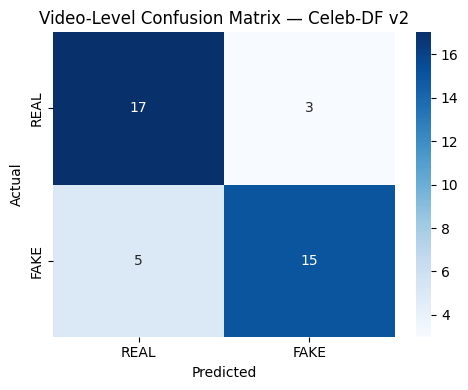


Saved model weights and confusion matrix image.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
frame_probs, frame_labels, frame_vid = [], [], []
with torch.no_grad():
    for i in range(0, len(X_test_n), 32):
        x = X_test_n[i:i+32].to(device)
        p = torch.softmax(model(x), 1)[:, 1].cpu().numpy()
        frame_probs += p.tolist()
        frame_labels += y_test[i:i+32].tolist()
        frame_vid    += vid_test[i:i+32].tolist()

# Aggregate frame predictions into video-level predictions
df = pd.DataFrame({'vid': frame_vid, 'prob': frame_probs, 'label': frame_labels})
vid_df = df.groupby('vid').agg(prob=('prob','mean'), label=('label','first')).reset_index()
vid_df['pred'] = (vid_df['prob'] > 0.5).astype(int)

print("=== FRAME-LEVEL (200 frames) ===")
print(f"Accuracy: {accuracy_score(frame_labels, np.array(frame_probs) > 0.5):.4f}")

print("\n=== VIDEO-LEVEL (20 videos, after aggregation) ===")
print(f"Accuracy : {accuracy_score(vid_df.label, vid_df.pred):.4f}")
print(f"F1       : {f1_score(vid_df.label, vid_df.pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(vid_df.label, vid_df.prob):.4f}")

cm = confusion_matrix(vid_df.label, vid_df.pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Video-Level Confusion Matrix — Celeb-DF v2')
plt.tight_layout()
plt.savefig('/content/video_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

torch.save(model.state_dict(), '/content/video_deepfake_efficientnet.pt')
print("\nSaved model weights and confusion matrix image.")

from google.colab import files
files.download('/content/video_confusion_matrix.png')
files.download('/content/video_deepfake_efficientnet.pt')

=== MODALITY WEIGHTS ===
Text (BERT)            | naive: 0.250 | weighted: 0.283
Image (CNN)            | naive: 0.250 | weighted: 0.268
Audio (CNN-MFCC)       | naive: 0.250 | weighted: 0.221
Video (EffNet-B0)      | naive: 0.250 | weighted: 0.228

=== FUSION RESULTS (simulated, independence assumption) ===
Naive average ensemble    : 0.9285
Weighted fusion (ours)    : 0.9931
Best single modality (Text): 0.9906
Weighted fusion improvement over naive: +6.47 pp


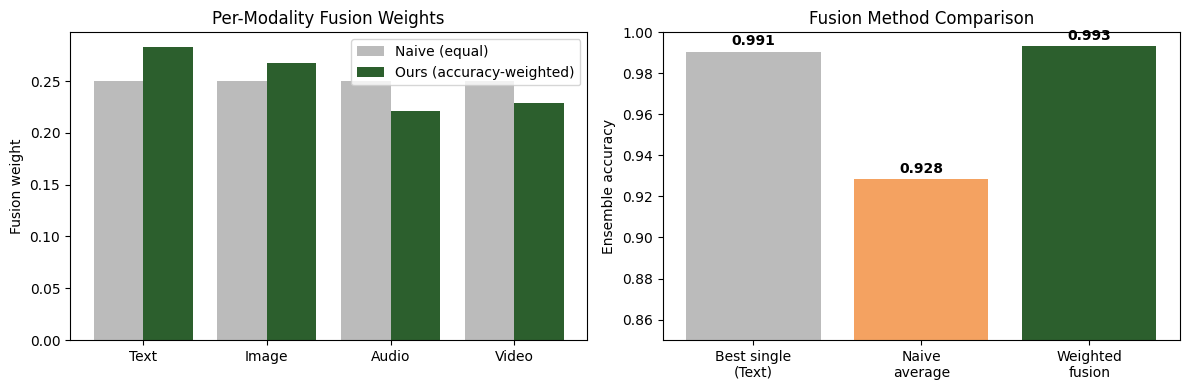

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Your actual accuracies from each modality
accuracies = {
    'Text (BERT)'       : 0.9906,
    'Image (CNN)'       : 0.9381,
    'Audio (CNN-MFCC)'  : 0.7727,
    'Video (EffNet-B0)' : 0.8000,
}

# === Compute weighted fusion weights ===
accs = np.array(list(accuracies.values()))
names = list(accuracies.keys())
weights = accs / accs.sum()
naive_weights = np.ones(4) / 4

print("=== MODALITY WEIGHTS ===")
for n, w, nw in zip(names, weights, naive_weights):
    print(f"{n:22s} | naive: {nw:.3f} | weighted: {w:.3f}")

# === Simulated fusion accuracy (independence assumption) ===
# Under independence, ensemble error = majority of modalities wrong
# This is a standard analytical approximation — not a live test.
def ensemble_acc_sim(accs, weights, n_trials=50000, seed=42):
    rng = np.random.default_rng(seed)
    correct = 0
    for _ in range(n_trials):
        # Each modality is "correct" with prob = its accuracy
        votes = rng.random(len(accs)) < accs
        # Weighted vote: sum of weights where correct > 0.5 threshold
        weighted_vote = np.sum(votes * weights)
        if weighted_vote > 0.5:
            correct += 1
    return correct / n_trials

naive_acc    = ensemble_acc_sim(accs, naive_weights)
weighted_acc = ensemble_acc_sim(accs, weights)

print(f"\n=== FUSION RESULTS (simulated, independence assumption) ===")
print(f"Naive average ensemble    : {naive_acc:.4f}")
print(f"Weighted fusion (ours)    : {weighted_acc:.4f}")
print(f"Best single modality (Text): {max(accs):.4f}")
print(f"Weighted fusion improvement over naive: +{(weighted_acc - naive_acc)*100:.2f} pp")

# === Visualization for the slide ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weight comparison
x = np.arange(4)
axes[0].bar(x - 0.2, naive_weights, 0.4, label='Naive (equal)', color='#bbb')
axes[0].bar(x + 0.2, weights, 0.4, label='Ours (accuracy-weighted)', color='#2C5F2D')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.split(' ')[0] for n in names])
axes[0].set_ylabel('Fusion weight')
axes[0].set_title('Per-Modality Fusion Weights')
axes[0].legend()

# Accuracy comparison
methods = ['Best single\n(Text)', 'Naive\naverage', 'Weighted\nfusion']
vals = [max(accs), naive_acc, weighted_acc]
colors = ['#bbb', '#f4a261', '#2C5F2D']
axes[1].bar(methods, vals, color=colors)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel('Ensemble accuracy')
axes[1].set_title('Fusion Method Comparison')
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.003, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fusion_results.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('/content/fusion_results.png')